In [1]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# import scikit learn and the metrics and the model
# linear regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# data set
data = {
    "Hours_Studied": [
        1, 2, 2.5, 3, 3.5, 4, 4.5,
        5, 5.5, 6, 6.5, 7, 7.5, 8,
        8.5, 9, 9.5, 10
    ],

    "Marks": [
        35, 39, 43, 47, 50, 54, 57,
        61, 64, 67, 70, 73, 77, 80,
        82, 86, 88, 92
    ]
}

df = pd.DataFrame(data)

df.head()

,Hours_Studied,Marks
0,1.0,35
1,2.0,39
2,2.5,43
3,3.0,47
4,3.5,50


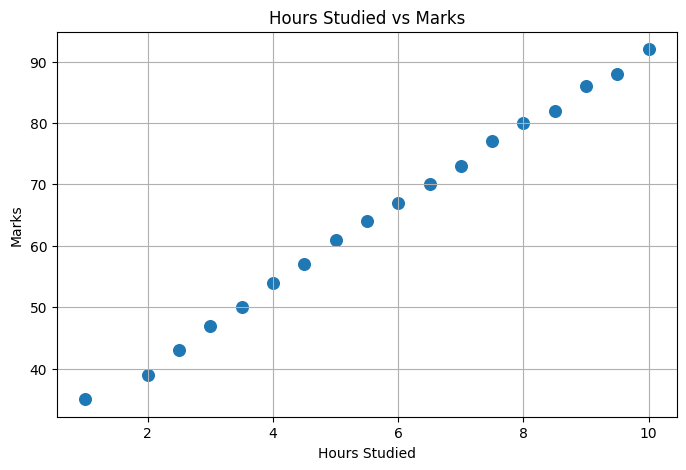

In [4]:
# graph to visualize the data
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Hours_Studied"],
    df["Marks"],
    s=70
)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours Studied vs Marks")

plt.grid(True)
plt.show()

In [5]:
# seperate x and y
X = df[["Hours_Studied"]]
y = df["Marks"]

In [6]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# 80 percent ha traning
# 20 percent use kare ge testing k leye

In [7]:
# create the model
model = LinearRegression()


In [8]:
model.fit(X_train, y_train)


LinearRegression()

In [9]:
# what did model learn, equations k parts ki value dekhte ha
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 6.44908142435927
Intercept: 27.811295078249003


In [10]:
# marks = 27 + 6.4 * hours

In [12]:
# now the prediction
prediction = model.predict([[7]])

print("Predicted Marks:", prediction[0])

Predicted Marks: 72.95486504876389


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [13]:
# new students k leye predict karo jin ka output hamare pass nahi
new_students = pd.DataFrame({
    "Hours_Studied": [2, 5, 7, 8.5, 10]
})

predictions = model.predict(new_students)

result = new_students.copy()
result["Predicted_Marks"] = predictions

result

,Hours_Studied,Predicted_Marks
0,2.0,40.709458
1,5.0,60.056702
2,7.0,72.954865
3,8.5,82.628487
4,10.0,92.302109


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


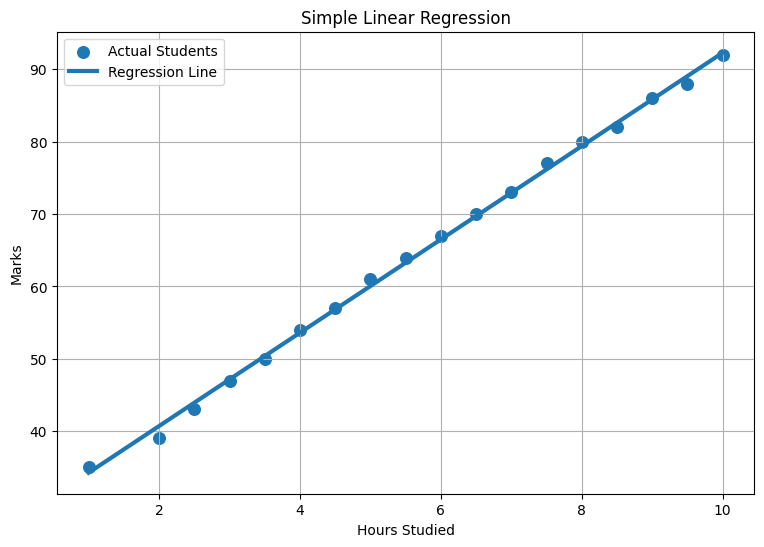

In [14]:
# important graph to visualize the linear regression line
plt.figure(figsize=(9, 6))

# Actual data
plt.scatter(
    X,
    y,
    s=70,
    label="Actual Students"
)

# Model predictions across the range
x_line = np.linspace(
    X["Hours_Studied"].min(),
    X["Hours_Studied"].max(),
    100
).reshape(-1, 1)

y_line = model.predict(x_line)

plt.plot(
    x_line,
    y_line,
    linewidth=3,
    label="Regression Line"
)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Simple Linear Regression")
plt.legend()
plt.grid(True)

plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


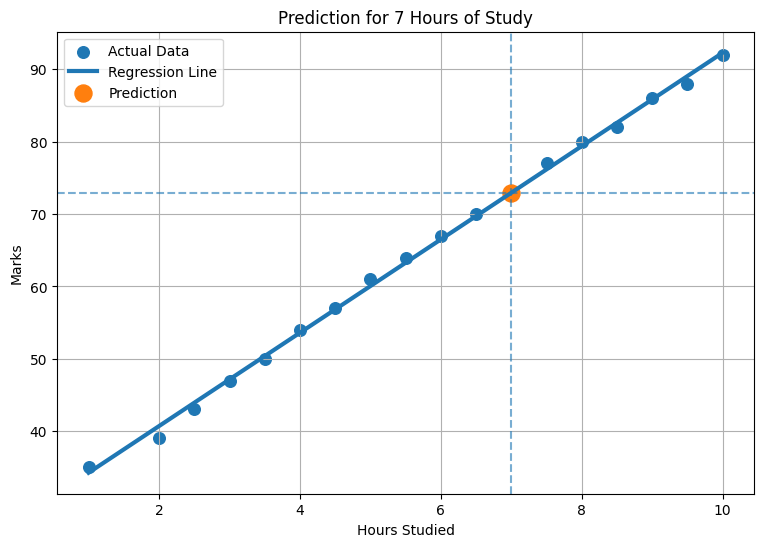

Hours Studied: 7
Predicted Marks: 72.95


In [15]:
# prediction visually
hours = 7

predicted_marks = model.predict([[hours]])[0]

plt.figure(figsize=(9, 6))

plt.scatter(
    X,
    y,
    s=70,
    label="Actual Data"
)

plt.plot(
    x_line,
    y_line,
    linewidth=3,
    label="Regression Line"
)

plt.scatter(
    [hours],
    [predicted_marks],
    s=150,
    label="Prediction"
)

plt.axvline(hours, linestyle="--", alpha=0.6)
plt.axhline(predicted_marks, linestyle="--", alpha=0.6)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title(f"Prediction for {hours} Hours of Study")

plt.legend()
plt.grid(True)

plt.show()

print(f"Hours Studied: {hours}")
print(f"Predicted Marks: {predicted_marks:.2f}")

In [16]:
# actual vs predicted
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,35,34.260377
1,39,40.709458
2,64,63.281243
3,54,53.607621


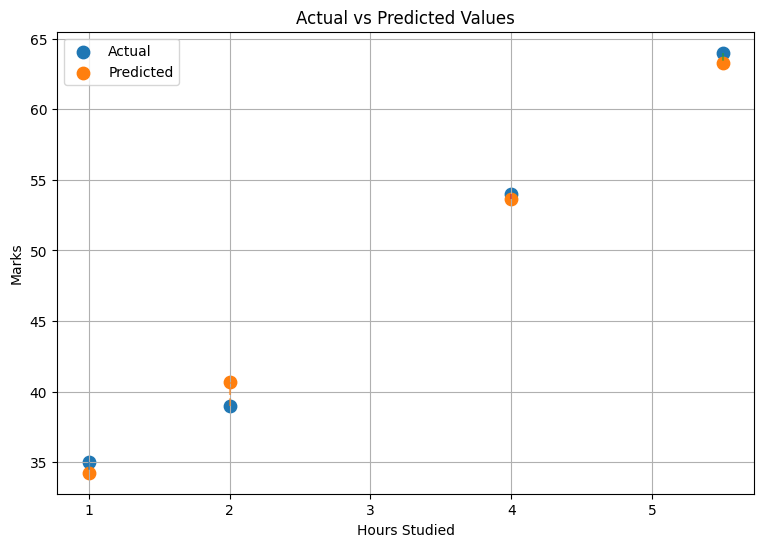

In [17]:
# lets see the errors visually
plt.figure(figsize=(9, 6))

plt.scatter(
    X_test,
    y_test,
    s=80,
    label="Actual"
)

plt.scatter(
    X_test,
    y_pred,
    s=80,
    label="Predicted"
)

for actual_x, actual_y, predicted_y in zip(
    X_test["Hours_Studied"],
    y_test,
    y_pred
):
    plt.plot(
        [actual_x, actual_x],
        [actual_y, predicted_y],
        linestyle="--",
        alpha=0.6
    )

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Actual vs Predicted Values")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
# model scores
# MAE
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.8900544341120487


In [19]:
# RMSE
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE:", rmse)

RMSE: 1.0173326064844952


In [20]:
# R ^ 2
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9923618772530145
